<a href="https://colab.research.google.com/github/fran-silva01/Treinando/blob/main/Treinando.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Treinando meus conhecimentos

CSV de vendas (vendas_lojas_agosto.csv)

Responder as seguintes perguntas:
1. Qual loja teve o maior faturamento total no período?
2. Qual categoria vende mais: Moda ou Casa?
3. Quem foi o vendedor com melhor desempenho em faturamento?
4. Existe alguma região performando visivelmente pior que as outras?

Extra:verificar se o faturamento está concentrado em poucas lojas ou regiões.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Leitura do csv
df = pd.read_csv('vendas_lojas_agosto.csv')
df.head()


,data,loja,regiao,categoria,produto,quantidade,preco_unitario,vendedor
0,2026-08-01,Loja Recife Centro,Nordeste,Moda,Camiseta Basica,12,49.9,Ana Souza
1,2026-08-01,Loja Recife Centro,Nordeste,Casa,Jogo de Toalhas,3,89.9,Ana Souza
2,2026-08-01,Loja SP Paulista,Sudeste,Moda,Calca Jeans,8,129.9,Bruno Lima
3,2026-08-01,Loja SP Paulista,Sudeste,Moda,Camiseta Basica,20,49.9,Bruno Lima
4,2026-08-02,Loja Recife Centro,Nordeste,Casa,Panela Antiaderente,5,159.9,Ana Souza


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   data            30 non-null     object 
 1   loja            30 non-null     object 
 2   regiao          30 non-null     object 
 3   categoria       30 non-null     object 
 4   produto         30 non-null     object 
 5   quantidade      30 non-null     int64  
 6   preco_unitario  30 non-null     float64
 7   vendedor        30 non-null     object 
dtypes: float64(1), int64(1), object(6)
memory usage: 2.0+ KB


In [5]:
df.describe()

,quantidade,preco_unitario
count,30.000000,30.000000
mean,7.500000,151.233333
std,4.629367,65.058771
min,2.000000,49.900000
25%,4.000000,89.900000
50%,6.000000,159.900000
75%,9.750000,199.900000
max,20.000000,249.900000


## 1. Qual loja teve o maior faturamento total no período?

In [33]:
# Calcula o faturamento
df['Fatutamento'] = df['quantidade'] * df['preco_unitario']

# Soma o faturamento por loja
faturamento_lojas = df.groupby('loja')['Fatutamento'].sum().sort_values(ascending=False)

# Loja com maior faturamento
maior_faturamento = faturamento_lojas.idxmax() # idxmax retorna o índice da primeira ocorrência do maior valor
maior_faturamento_valor = faturamento_lojas.max()

# Print
print('Loja com maior faturamento:', maior_faturamento)
print('------------------------------')
print('Faturamento total por loja:', faturamento_lojas)

Loja com maior faturamento: Loja SP Paulista
------------------------------
Faturamento total por loja: loja
Loja SP Paulista       7454.5
Loja RJ Barra          5046.8
Loja Recife Centro     4506.3
Loja BH Savassi        4166.5
Loja POA Moinhos       3558.2
Loja Curitiba Batel    2896.9
Loja Salvador Barra    2498.3
Name: Fatutamento, dtype: float64


## 2. Qual categoria vende mais: Moda ou Casa?

In [27]:
# Por quantidade
vendas = df[df["categoria"].isin(["Moda", "Casa"])].groupby("categoria")["quantidade"].sum()

vendas

,quantidade
categoria,
Casa,59
Moda,166


In [8]:
# Por faturamento
df["faturamento"] = df["quantidade"] * df["preco_unitario"]

faturamento_categoria = (
    df[df["categoria"].isin(["Moda", "Casa"])]
    .groupby("categoria")["faturamento"]
    .sum()
)

print(faturamento_categoria)
print("Categoria com maior faturamento:", faturamento_categoria.idxmax())


categoria
Casa     8034.1
Moda    22093.4
Name: faturamento, dtype: float64
Categoria com maior faturamento: Moda


## 3. Quem foi o vendedor com melhor desempenho em faturamento?

In [28]:
faturamento_vendedor = df.groupby("vendedor")["faturamento"].sum()

faturamento_vendedor

,faturamento
vendedor,
Ana Souza,4506.3
Bruno Lima,7454.5
Carla Dias,5046.8
Diego Alves,3558.2
Elaine Rocha,4166.5
Fabio Nunes,2498.3
Gustavo Melo,2896.9


In [13]:
melhor_vendedor = faturamento_vendedor.idxmax()
maior_faturamento = faturamento_vendedor.max()

print("Vendedor com maior faturamento:", melhor_vendedor)
print("Faturamento:", maior_faturamento)

Vendedor com maior faturamento: Bruno Lima
Faturamento: 7454.5


## 4. Existe alguma região performando visivelmente pior que as outras?

In [14]:
faturamento_regiao = df.groupby("regiao")["faturamento"].sum()

faturamento_regiao

,faturamento
regiao,
Nordeste,7004.6
Sudeste,16667.8
Sul,6455.1


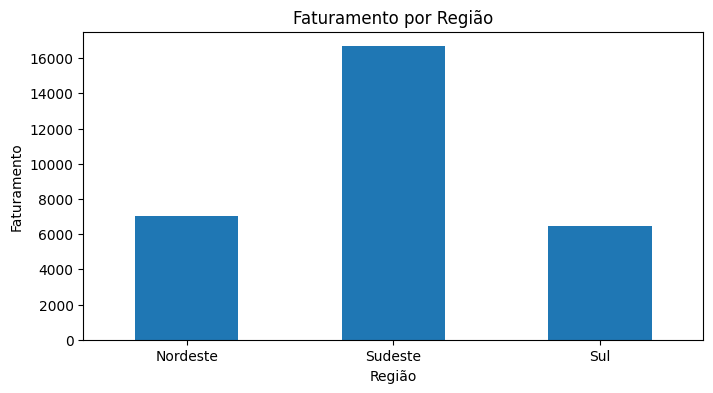

In [20]:
# Gráfico de barras
plt.figure(figsize=(8, 4))
faturamento_regiao.plot(kind="bar")

plt.title("Faturamento por Região")
plt.xlabel("Região")
plt.ylabel("Faturamento")
plt.xticks(rotation=0)
plt.show()

Como as regiões possuem quantidades diferentes de lojas ( o Sudeste possui 3 lojas, enquanto Nordeste e Sul possuem 2) a comparação do faturamento total pode ser influenciada pelo número de estabelecimentos de cada região. Para tornar a comparação mais equilibrada, realizei um ajuste do faturamento pelo número de lojas, calculando o faturamento médio por loja em cada região. Dessa forma, é possível avaliar o desempenho das regiões considerando a quantidade de lojas e obter uma comparação mais próxima do desempenho individual dos estabelecimentos.


In [29]:
# Faturamento médio por LOJA em cada região (normalizado)
faturamento_regiao = df.groupby('regiao')['faturamento'].sum()
lojas_por_regiao = df.groupby('regiao')['loja'].nunique()
media_por_loja = faturamento_regiao / lojas_por_regiao
print(media_por_loja.sort_values(ascending=False))

regiao
Sudeste     5555.933333
Nordeste    3502.300000
Sul         3227.550000
dtype: float64


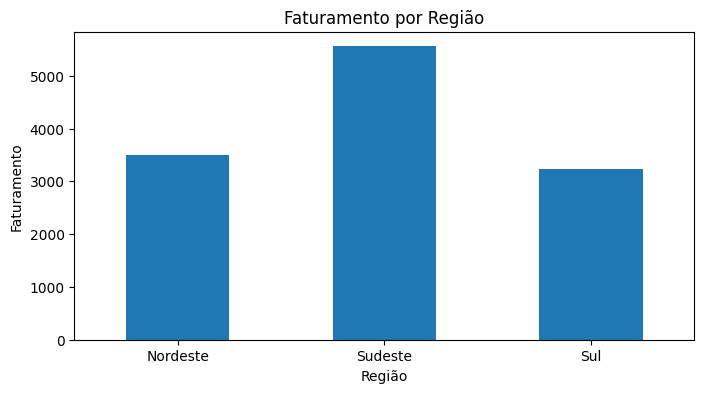

In [31]:
# Gráfico de barras
plt.figure(figsize=(8, 4))
media_por_loja.plot(kind="bar")

plt.title("Faturamento por Região")
plt.xlabel("Região")
plt.ylabel("Faturamento")
plt.xticks(rotation=0)
plt.show()

## Extra: verificar se o faturamento está concentrado em poucas lojas ou regiões.

In [34]:
total = df['faturamento'].sum()

# % que cada loja representa do total
percentual = (faturamento_lojas / total * 100).round(1)
print(percentual)

# Quanto as 2 maiores lojas juntas representam do total?
print("Top 2 lojas:", percentual.head(2).sum(), "%")

loja
Loja SP Paulista       24.7
Loja RJ Barra          16.8
Loja Recife Centro     15.0
Loja BH Savassi        13.8
Loja POA Moinhos       11.8
Loja Curitiba Batel     9.6
Loja Salvador Barra     8.3
Name: Fatutamento, dtype: float64
Top 2 lojas: 41.5 %


O faturamento está concentrado: 3 das 7 lojas (43% do total de lojas) respondem por 56,5% da receita. Recomenda-se investigar o que essas lojas fazem de diferente (mix de produtos, tráfego, localização) para replicar boas práticas nas demais e monitorar de perto o risco de dependência excessiva dessas unidades."